In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import os

In [2]:
def count_per_class(path, name):
    print(f"\n{name}:")
    total = 0

    for cls in os.listdir(path):
        class_path = os.path.join(path, cls)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(f"{cls} : {count} images")
            total += count

    print("Total images:", total)

dataset_path = "/content/Dataset"
count_per_class(dataset_path, "Dataset")


Dataset:
Leaf smut : 40 images
Brown spot : 40 images
Bacterial leaf blight : 40 images
Total images: 120


In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [4]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(3, activation='softmax')
])

In [5]:
print("\nAfter splitting:")
print("Training samples:", train_data.samples)
print("Validation samples:", val_data.samples)


After splitting:
Training samples: 96
Validation samples: 24


In [6]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


In [12]:
model = models.Sequential([

    layers.Input(shape=(128,128,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(3, activation='softmax')
])


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2917 - loss: 1.1676 - val_accuracy: 0.3333 - val_loss: 1.1005
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2812 - loss: 1.1107 - val_accuracy: 0.3333 - val_loss: 1.0889
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4167 - loss: 1.0789 - val_accuracy: 0.5417 - val_loss: 1.0451
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5000 - loss: 1.0421 - val_accuracy: 0.4583 - val_loss: 1.0005
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 750ms/step - accuracy: 0.5208 - loss: 0.9725 - val_accuracy: 0.3750 - val_loss: 0.9553
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 752ms/step - accuracy: 0.4271 - loss: 0.9760 - val_accuracy: 0.6667 - val_loss: 0.8593
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 987ms/step - accuracy: 0.5000 - loss: 0.9276 - val_accuracy: 0.4167 - val_loss: 0.9341
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 744ms/step - accuracy: 0.6042 - loss: 0.8961 - val_accuracy: 0.5417 - val_loss: 0.8040
Epo

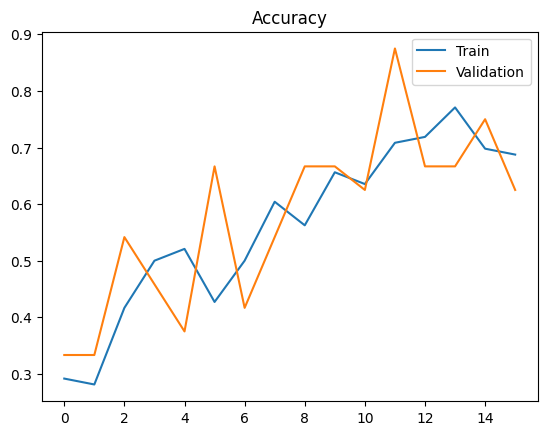

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Accuracy')
plt.show()

In [17]:
val_data.reset()

pred = model.predict(val_data)

y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step


In [18]:
labels = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00         8
           Brown spot       0.78      0.88      0.82         8
            Leaf smut       0.86      0.75      0.80         8

             accuracy                           0.88        24
            macro avg       0.88      0.88      0.87        24
         weighted avg       0.88      0.88      0.87        24



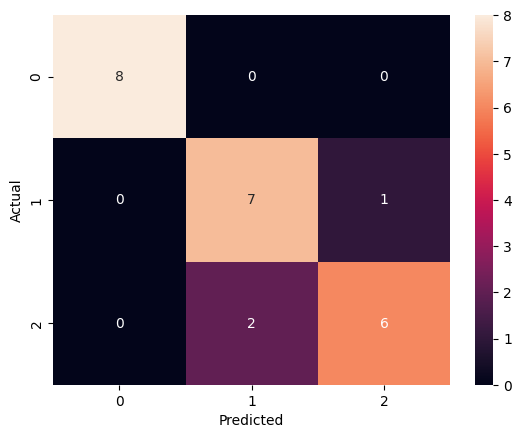

In [19]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()